In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
file_path = 'data/Walmart.csv'
df = pd.read_csv(file_path)

In [3]:
df.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


In [4]:
print("--- Tỉ lệ dữ liệu khuyết thiếu (NaN) trên từng cột ---")
nan_ratio = df.isnull().mean()
print(nan_ratio)
print("-" * 50)

--- Tỉ lệ dữ liệu khuyết thiếu (NaN) trên từng cột ---
Store           0.0
Date            0.0
Weekly_Sales    0.0
Holiday_Flag    0.0
Temperature     0.0
Fuel_Price      0.0
CPI             0.0
Unemployment    0.0
dtype: float64
--------------------------------------------------


In [5]:
df['Store'].value_counts()

Store
1     143
2     143
3     143
4     143
5     143
6     143
7     143
8     143
9     143
10    143
11    143
12    143
13    143
14    143
15    143
16    143
17    143
18    143
19    143
20    143
21    143
22    143
23    143
24    143
25    143
26    143
27    143
28    143
29    143
30    143
31    143
32    143
33    143
34    143
35    143
36    143
37    143
38    143
39    143
40    143
41    143
42    143
43    143
44    143
45    143
Name: count, dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values(by='Date').reset_index(drop=True)

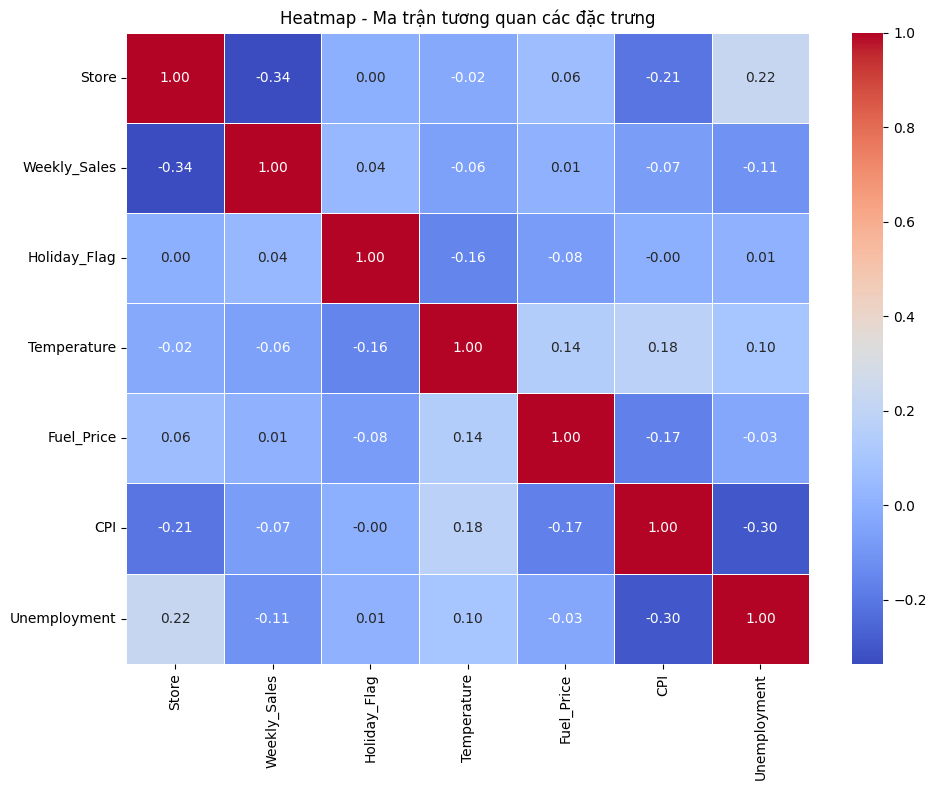

In [7]:
corr_matrix = df.drop(columns=['Date']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap - Ma trận tương quan các đặc trưng')
plt.tight_layout()
plt.show()

## - Cách làm trên là đang áp dụng công cụ dành riêng cho biến liên tục lên dữ liệu phân loại. Dẫn đến sai hướng. 
## - .corr() là hệ số tương quan Person thiết kế để  đo lường mối quan hệ tuyến tính giữa 2 biến định lượng (liên tục). Và việc xem một biến phân loại như biến định lượng là đã sai ở mặt tư duy
## ==> ta cần phân tách thành 2 nhóm biến để xem sự tương quan, mối quan hệ của 2 nhóm biến với biến mục tiêu


## Chưa chính xác 


In [8]:
train_list = []
test_list = []

# Duyệt qua từng Store để đảm bảo tỉ lệ chia tách 80/20 đồng đều theo chuỗi thời gian của từng store
for store_id, group in df.groupby('Store'):
    # Đảm bảo dữ liệu trong store được sắp xếp theo thời gian tăng dần
    group = group.sort_values('Date')
    split_idx = int(len(group) * 0.8)
    
    train_list.append(group.iloc[:split_idx])
    test_list.append(group.iloc[split_idx:])

# Gộp lại thành tập dữ liệu Train và Test hoàn chỉnh
train_df = pd.concat(train_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)

print(f"Kích thước tập huấn luyện (Train): {train_df.shape}")
print(f"Kích thước tập kiểm thử (Test): {test_df.shape}")
print("-" * 50)

Kích thước tập huấn luyện (Train): (5130, 8)
Kích thước tập kiểm thử (Test): (1305, 8)
--------------------------------------------------


In [9]:
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

X_train_raw = train_df[features]
y_train = train_df['Weekly_Sales']
X_test_raw = test_df[features]
y_test = test_df['Weekly_Sales']

In [10]:
X_train_raw.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,0,42.31,2.572,211.096358,8.106
1,1,1,38.51,2.548,211.242170,8.106
2,1,0,39.93,2.514,211.289143,8.106
3,1,0,46.63,2.561,211.319643,8.106
4,1,0,46.50,2.625,211.350143,8.106


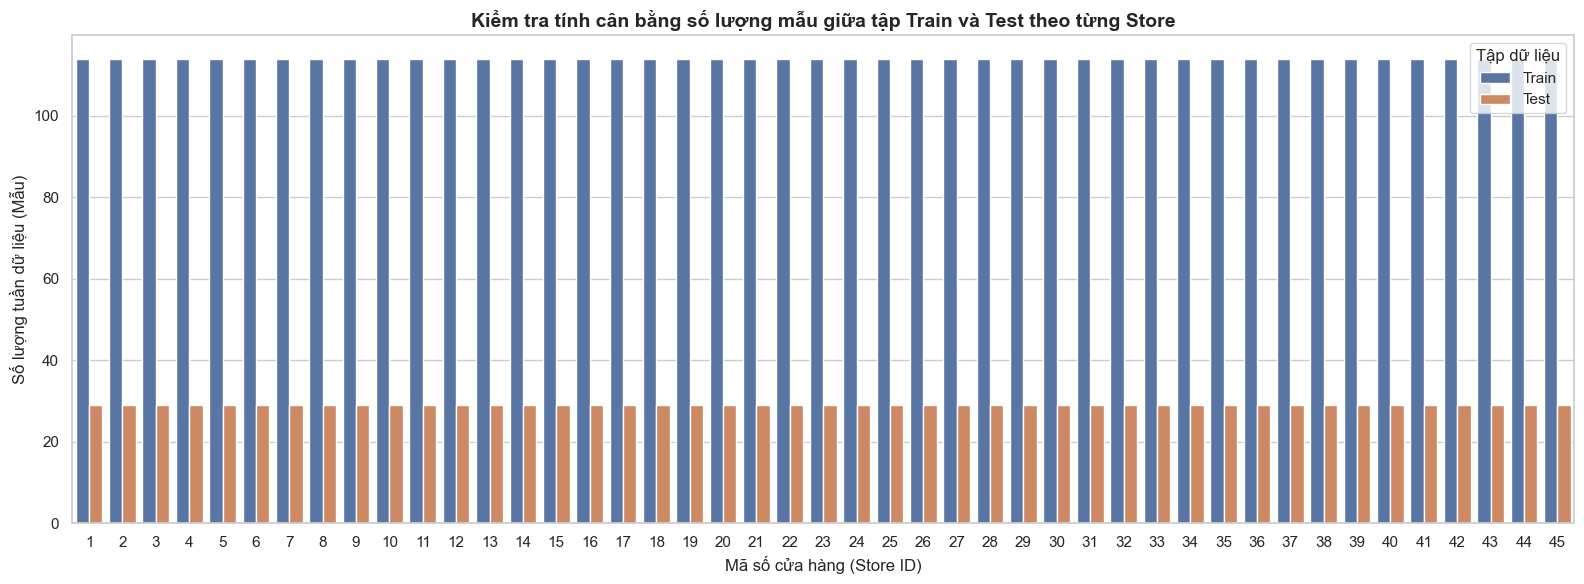

In [11]:
# Đánh dấu nhãn tập dữ liệu để trực quan hóa
train_df['Dataset'] = 'Train'
test_df['Dataset'] = 'Test'
# Gộp chung lại phục vụ cho việc vẽ biểu đồ so sánh
combined_df = pd.concat([train_df, test_df], axis=0)

# Cấu hình giao diện đồ họa
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(16, 6))
sns.countplot(
    data=combined_df, 
    x='Store', 
    hue='Dataset', 
    palette={'Train': '#4C72B0', 'Test': '#DD8452'}, 
    ax=ax
)

ax.set_title('Kiểm tra tính cân bằng số lượng mẫu giữa tập Train và Test theo từng Store', fontsize=14, fontweight='bold')
ax.set_xlabel('Mã số cửa hàng (Store ID)', fontsize=12)
ax.set_ylabel('Số lượng tuần dữ liệu (Mẫu)', fontsize=12)
ax.legend(title='Tập dữ liệu')

plt.tight_layout()
plt.show()

In [12]:
# Thêm cột hằng số (Intercept) bắt buộc cho mô hình statsmodels.api
X_train = sm.add_constant(X_train_raw)
X_test = sm.add_constant(X_test_raw)

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []

In [14]:
fold = 1
for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Huấn luyện mô hình hồi quy tuyến tính OLS bằng statsmodels
    model_cv = sm.OLS(y_tr, X_tr).fit()
    
    # Dự báo trên tập validation của fold hiện tại
    y_pred_val = model_cv.predict(X_val)
    
    # Tính toán các chỉ số đánh giá
    r2_f = r2_score(y_val, y_pred_val)
    rmse_f = np.sqrt(mean_squared_error(y_val, y_pred_val))
    
    cv_r2_scores.append(r2_f)
    cv_rmse_scores.append(rmse_f)
    
    print(f"Fold {fold}: R-squared = {r2_f:.4f} | RMSE = {rmse_f:.2f}")
    fold += 1

print(f"\n>> Trung bình CV R-squared: {np.mean(cv_r2_scores):.4f}")
print(f"\n>> Trung bình CV RMSE: {np.mean(cv_rmse_scores):.2f}")
print("-" * 50)

Fold 1: R-squared = 0.1436 | RMSE = 511374.26
Fold 2: R-squared = 0.1340 | RMSE = 544716.50
Fold 3: R-squared = 0.1465 | RMSE = 553565.02
Fold 4: R-squared = 0.1468 | RMSE = 525861.02
Fold 5: R-squared = 0.1089 | RMSE = 516994.34

>> Trung bình CV R-squared: 0.1360

>> Trung bình CV RMSE: 530502.23
--------------------------------------------------


In [15]:
final_model = sm.OLS(y_train, X_train).fit()
y_pred_test = final_model.predict(X_test)

In [16]:
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Weekly_Sales   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     140.6
Date:                Mon, 25 May 2026   Prob (F-statistic):          1.58e-165
Time:                        13:37:04   Log-Likelihood:                -74895.
No. Observations:                5130   AIC:                         1.498e+05
Df Residuals:                    5123   BIC:                         1.498e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.961e+06   8.44e+04     23.239      0.000     1.8e+06    2.13e+06
Store         -1.56e+04    592.521    -26.334      0.000   -1.68e+04   -1.44e+04
Holiday_Flag  7.759e+04   2.79e+04      2.779      0.005    2.29e+04    1.32e+05
Temperature   -906.6931    420.561     -2.156      0.031   -1731.172     -82.214
Fuel_Price    2.044e+04    1.7e+04      1.202      0.229   -1.29e+04    5.38e+04
CPI          -2333.9520    211.577    -11.031      0.000   -2748.733   -1919.171
Unemployment -2.139e+04   4339.530     -4.928      0.000   -2.99e+04   -1.29e+04
==============================================================================
Omnibus:                      190.146   Durbin-Watson:                   0.156
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              211.513
Skew:                           0.480   Prob(JB):                     1.18e-46
Kurtosis:                       3.261   Cond. No.                     2.14e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
final_test_r2 = r2_score(y_test, y_pred_test)
final_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("--- Kết quả đánh giá cuối cùng trên tập Test độc lập ---")
print(f"Test R-squared: {final_test_r2:.4f}")
print(f"Test RMSE: {final_test_rmse:.2f}")
print("-" * 50)

--- Kết quả đánh giá cuối cùng trên tập Test độc lập ---
Test R-squared: 0.1411
Test RMSE: 494505.45
--------------------------------------------------


In [18]:
latest_date = df['Date'].max()
print(f"Ngày cuối cùng trong tập dữ liệu: {latest_date.strftime('%d-%m-%Y')}")
print(df[df['Date'] == latest_date].head())

Ngày cuối cùng trong tập dữ liệu: 26-10-2012
      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
6390     21 2012-10-26     675202.87             0        70.50       3.506   
6391     24 2012-10-26    1307182.29             0        55.16       4.071   
6392     32 2012-10-26    1219979.29             0        47.22       3.686   
6393      9 2012-10-26     549731.49             0        69.52       3.506   
6394     17 2012-10-26     943465.29             0        39.94       3.755   

             CPI  Unemployment  
6390  223.078337         6.170  
6391  138.728161         8.693  
6392  199.219532         7.557  
6393  227.232807         4.954  
6394  131.193097         5.527  


In [19]:
# 1. Tạo tập dữ liệu chứa thông tin đầu vào
future_df = pd.DataFrame({
    'Store': [20],
    'Date': [pd.to_datetime('2012-11-02')],
    'Holiday_Flag': [0],
    'Temperature': [32.0],
    'Fuel_Price': [2.756],
    'CPI': [206.854976],
    'Unemployment': [7.135]
})

# 2. Tạo ma trận X_future trống có các cột giống hệt X_train của bạn (7 cột)
X_future = pd.DataFrame(0.0, index=[0], columns=X_train.columns)

# 3. Gán trực tiếp giá trị vào các cột tương ứng
X_future['const'] = 1.0
X_future['Store'] = 20         
X_future['Holiday_Flag'] = 0.0
X_future['Temperature'] = 32.0
X_future['Fuel_Price'] = 2.756
X_future['CPI'] = 206.854976
X_future['Unemployment'] = 7.135

# 4. Dự đoán doanh số
future_df['Predicted_Weekly_Sales'] = final_model.predict(X_future)
print(future_df)

   Store       Date  Holiday_Flag  Temperature  Fuel_Price         CPI  \
0     20 2012-11-02             0         32.0       2.756  206.854976   

   Unemployment  Predicted_Weekly_Sales  
0         7.135            1.040810e+06  
